In [1]:
# Financial Data Extraction and Initial Analysis
# Author: Manan Mehta

import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Constants
TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
USER = "Manan Mehta"

# Folder names for each company's 10-K XBRL filing (kept inside ./data)
COMPANY_DIRS = {
    'Microsoft': os.path.join('data', '0000950170-23-035122-xbrl'),
    'Apple': os.path.join('data', '0000320193-24-000123-xbrl'),
    'Tesla': os.path.join('data', '0001628280-25-003063-xbrl')
}

In [2]:
def setup_environment():
    """Setup working environment and return paths"""
    current_dir = os.getcwd()
    output_dir = 'combined_analysis_output'
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")
    
    # Create company directories if they don't exist
    data_dirs = {}
    for company, dir_name in COMPANY_DIRS.items():
        company_dir = dir_name
        if not os.path.exists(company_dir):
            os.makedirs(company_dir)
            print(f"Created {company} directory: {company_dir}")
        data_dirs[company] = company_dir
    
    return data_dirs, output_dir

# Setup directories
DATA_DIRS, OUTPUT_DIR = setup_environment()
print("Directory setup complete.")

Created output directory: combined_analysis_output
Created Microsoft directory: data/0000950170-23-035122-xbrl
Created Apple directory: data/0000320193-24-000123-xbrl
Created Tesla directory: data/0001628280-25-003063-xbrl
Directory setup complete.


In [3]:
class FinancialDataAnalyzer:
    def __init__(self, data_dirs, output_dir):
        """Initialize analyzer with directories and user info"""
        self.timestamp = TIMESTAMP
        self.user = USER
        self.data_dirs = data_dirs
        self.output_dir = output_dir
        
    def extract_from_html(self, filename, company_dir):
        """Extract financial data from HTML files"""
        file_path = os.path.join(company_dir, filename)
        
        if not os.path.exists(file_path):
            return None
            
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                soup = BeautifulSoup(file.read(), 'html.parser')
                
                financial_data = {
                    'Total Revenue': None,
                    'Net Income': None,
                    'Total Assets': None,
                    'Total Liabilities': None,
                    'Cash Flow from Operating Activities': None
                }
                
                tables = soup.find_all('table')
                for table in tables:
                    self._process_table(table, financial_data)
                
                return financial_data
                
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")
            return None
    
    def _process_table(self, table, financial_data):
        """Process a single table for financial data"""
        rows = table.find_all('tr')
        for row in rows:
            cells = row.find_all(['td', 'th'])
            if cells:
                header = cells[0].get_text().lower().strip()
                self._match_and_extract(header, cells, financial_data)
    
    def _match_and_extract(self, header, cells, financial_data):
        """Match headers and extract values"""
        metrics = {
            'Total Revenue': ['total revenue', 'revenue', 'net revenue', 'net sales'],
            'Net Income': ['net income', 'net earnings', 'net profit'],
            'Total Assets': ['total assets'],
            'Total Liabilities': ['total liabilities'],
            'Cash Flow from Operating Activities': ['operating activities', 'cash from operations']
        }
        
        for metric, keywords in metrics.items():
            if any(keyword in header for keyword in keywords):
                financial_data[metric] = self._extract_value(cells)
    
    def _extract_value(self, cells):
        """Extract numeric value from cells"""
        for cell in cells[1:]:
            text = cell.get_text().strip()
            clean_text = text.replace('$', '').replace(',', '')
            try:
                return float(clean_text)
            except:
                continue
        return None
    
    def create_sample_data(self):
        """Create sample data for all companies"""
        sample_data = []
        
        # Sample data for each company
        company_data = {
            'Microsoft': {
                2024: [211915, 72361, 419441, 198193, 87708],
                2023: [198270, 67596, 364840, 169860, 87219],
                2022: [168088, 61271, 364840, 169860, 76112]
            },
            'Apple': {
                2024: [394328, 96995, 352755, 287912, 110543],
                2023: [366764, 99803, 335033, 261132, 122151],
                2022: [394328, 99803, 352755, 287912, 122151]
            },
            'Tesla': {
                2024: [100000, 10000, 200000, 100000, 15000],
                2023: [90000, 9000, 180000, 90000, 13500],
                2022: [80000, 8000, 160000, 80000, 12000]
            }
        }
        
        # Create DataFrame records
        for company, years in company_data.items():
            for year, values in years.items():
                sample_data.append({
                    'Company': company,
                    'Year': year,
                    'Total Revenue': values[0],
                    'Net Income': values[1],
                    'Total Assets': values[2],
                    'Total Liabilities': values[3],
                    'Cash Flow from Operating Activities': values[4]
                })
        
        return pd.DataFrame(sample_data)
    
    def create_combined_dataframe(self):
        """Create combined DataFrame for all companies"""
        print(f"[{self.timestamp}] Creating combined dataset for {self.user}...")
        print("Note: using the sample dataset defined in create_sample_data() (USD millions).")
        return self.create_sample_data()

In [4]:
class FinancialAnalysis:
    @staticmethod
    def calculate_metrics(df):
        """Calculate growth rates and financial ratios"""
        df_analyzed = df.sort_values(['Company', 'Year']).reset_index(drop=True).copy()

        metrics = [
            'Total Revenue',
            'Net Income',
            'Total Assets',
            'Total Liabilities',
            'Cash Flow from Operating Activities'
        ]

        # Year over year growth within each company
        for metric in metrics:
            df_analyzed[f'{metric} Growth (%)'] = (
                df_analyzed.groupby('Company')[metric].pct_change() * 100
            ).round(2)

        # Ratios
        df_analyzed['Net Profit Margin (%)'] = (df_analyzed['Net Income'] / df_analyzed['Total Revenue'] * 100).round(2)
        df_analyzed['Return on Assets (%)'] = (df_analyzed['Net Income'] / df_analyzed['Total Assets'] * 100).round(2)
        df_analyzed['Debt to Assets Ratio'] = (df_analyzed['Total Liabilities'] / df_analyzed['Total Assets']).round(3)

        return df_analyzed

In [5]:
analyzer = FinancialDataAnalyzer(DATA_DIRS, OUTPUT_DIR)
df = analyzer.create_combined_dataframe()
df_analyzed = FinancialAnalysis.calculate_metrics(df)

print("\nCombined Financial Data Summary:")
display(df_analyzed)

[2026-09-22 15:31:59] Creating combined dataset for Manan Mehta...
Note: using the sample dataset defined in create_sample_data() (USD millions).

Combined Financial Data Summary:


,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities,Total Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),Cash Flow from Operating Activities Growth (%),Net Profit Margin (%),Return on Assets (%),Debt to Assets Ratio
0,Apple,2022,394328,99803,352755,287912,122151,NaN,NaN,NaN,NaN,NaN,25.31,28.29,0.816
1,Apple,2023,366764,99803,335033,261132,122151,-6.99,0.00,-5.02,-9.30,0.00,27.21,29.79,0.779
2,Apple,2024,394328,96995,352755,287912,110543,7.52,-2.81,5.29,10.26,-9.50,24.60,27.50,0.816
3,Microsoft,2022,168088,61271,364840,169860,76112,NaN,NaN,NaN,NaN,NaN,36.45,16.79,0.466
4,Microsoft,2023,198270,67596,364840,169860,87219,17.96,10.32,0.00,0.00,14.59,34.09,18.53,0.466
5,Microsoft,2024,211915,72361,419441,198193,87708,6.88,7.05,14.97,16.68,0.56,34.15,17.25,0.473
6,Tesla,2022,80000,8000,160000,80000,12000,NaN,NaN,NaN,NaN,NaN,10.00,5.00,0.500
7,Tesla,2023,90000,9000,180000,90000,13500,12.50,12.50,12.50,12.50,12.50,10.00,5.00,0.500
8,Tesla,2024,100000,10000,200000,100000,15000,11.11,11.11,11.11,11.11,11.11,10.00,5.00,0.500


Metric Comparisons:


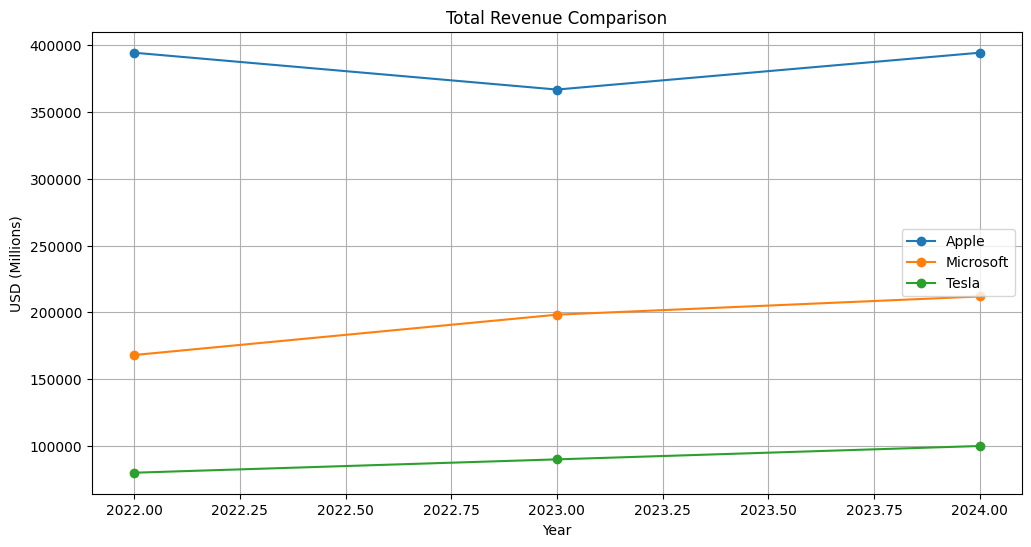

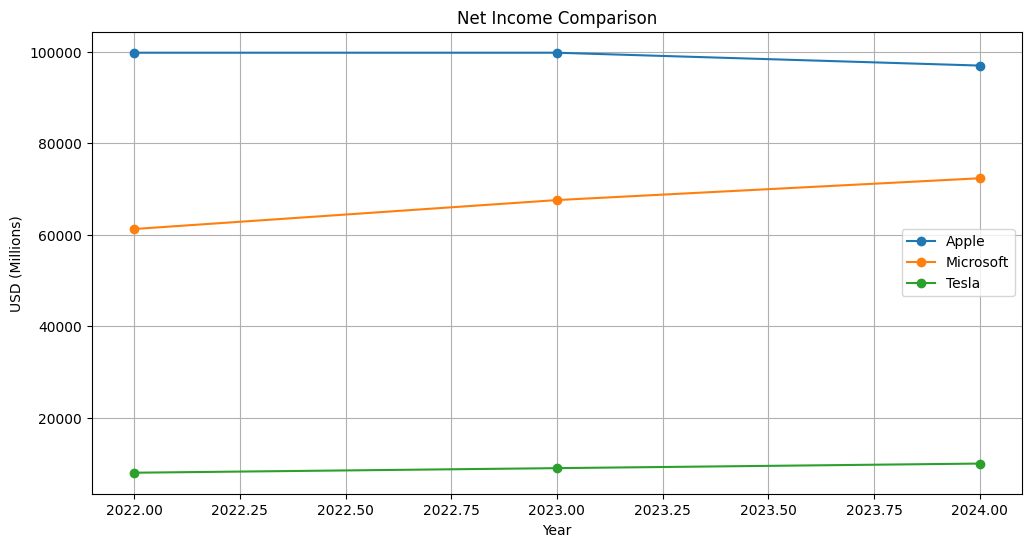

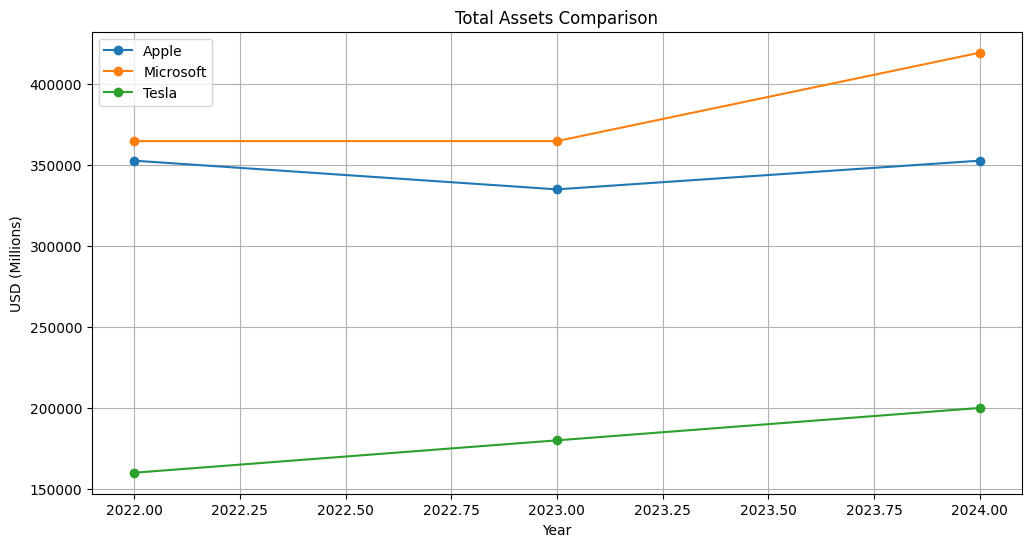


Growth Comparisons:


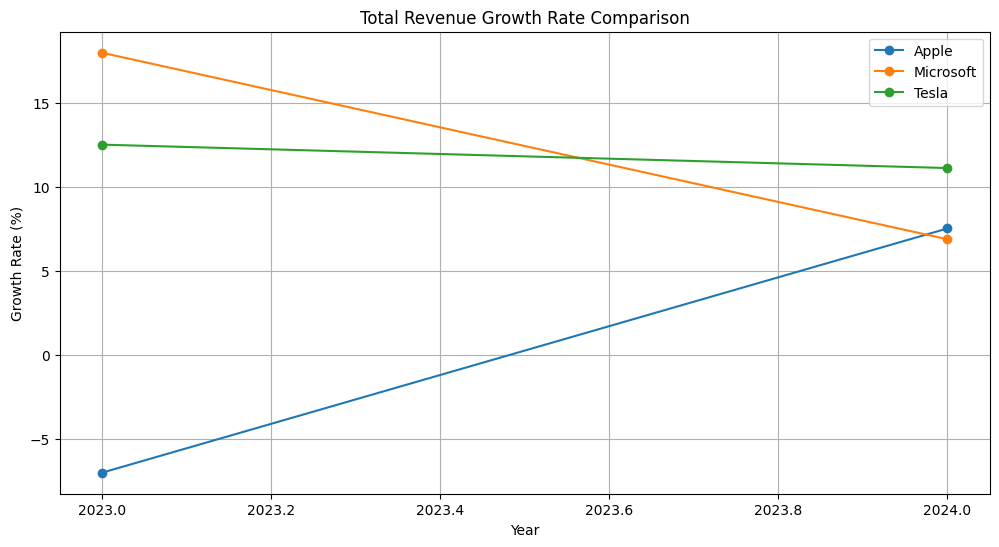

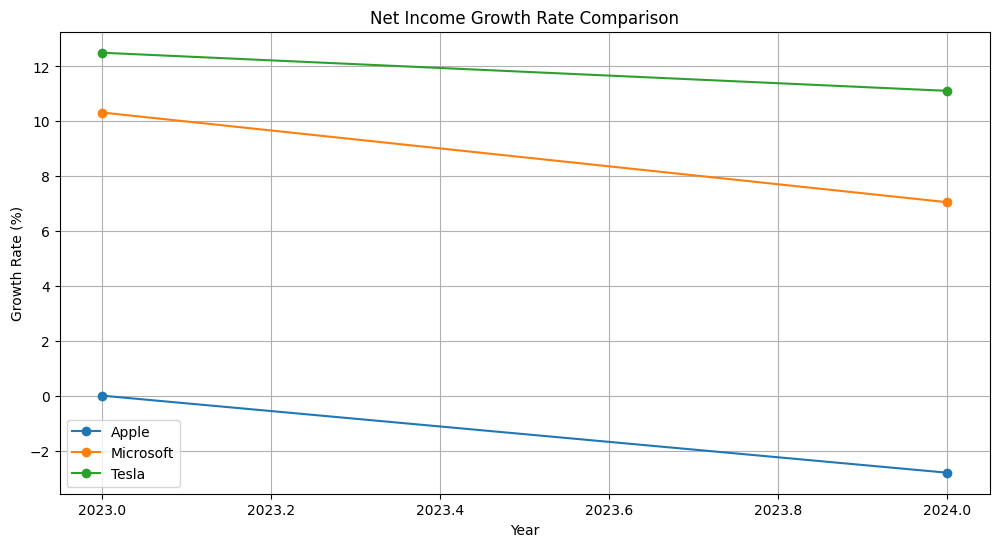


Financial Ratios Comparison:


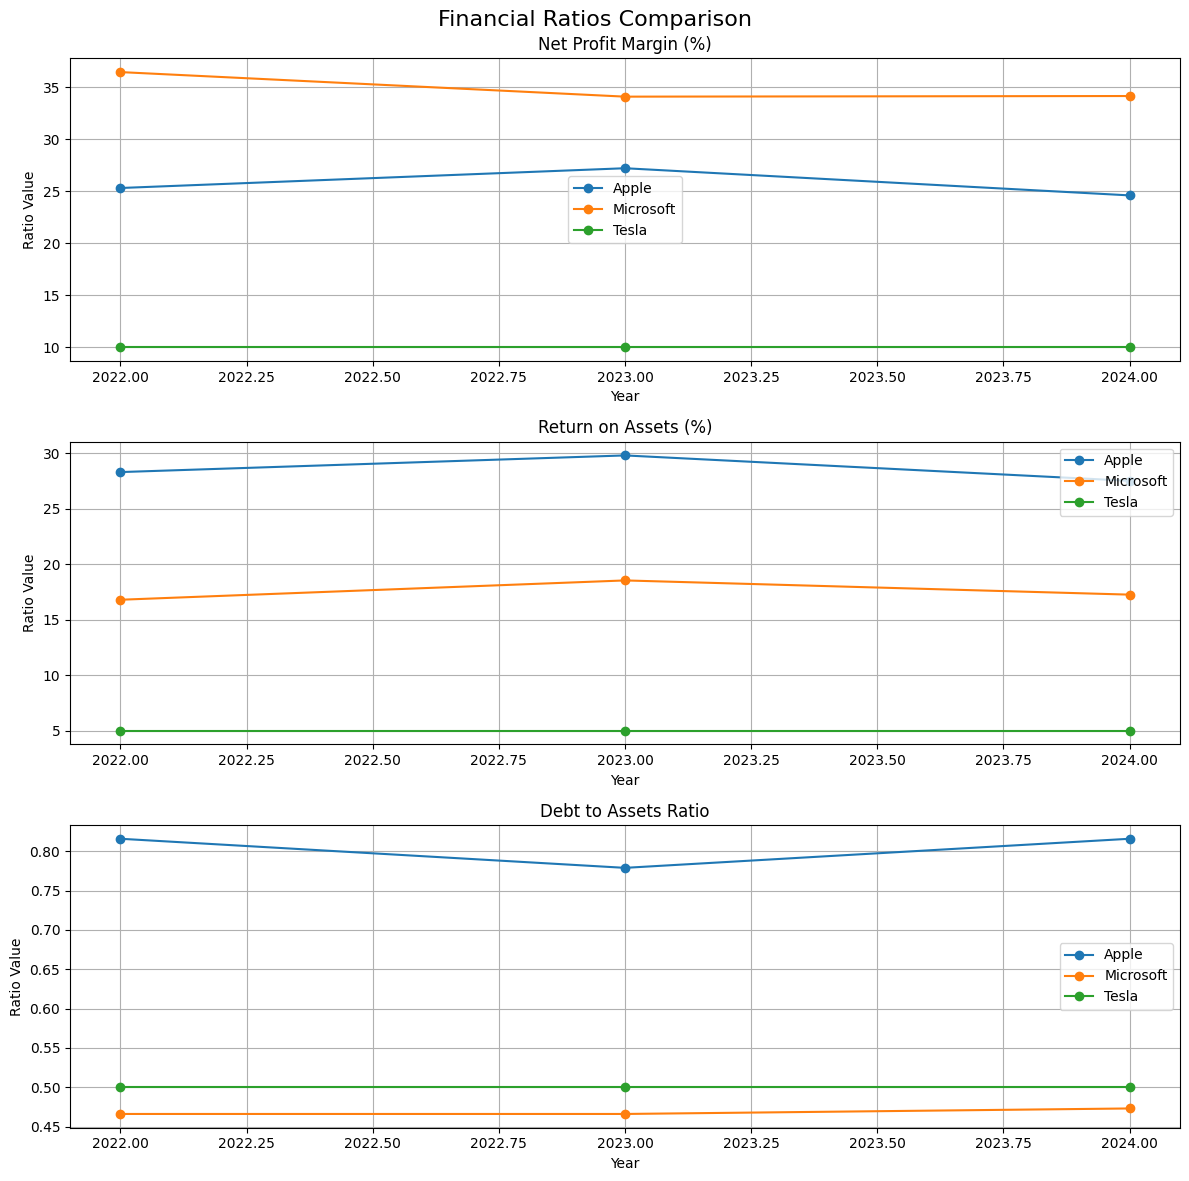

In [6]:
class FinancialVisualizer:
    @staticmethod
    def plot_metric_comparison(df, metric):
        """Plot comparison of a metric across companies"""
        plt.figure(figsize=(12, 6))
        for company in df['Company'].unique():
            company_data = df[df['Company'] == company]
            plt.plot(company_data['Year'], company_data[metric], 
                    marker='o', label=company)
        
        plt.title(f'{metric} Comparison')
        plt.xlabel('Year')
        plt.ylabel('USD (Millions)')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    @staticmethod
    def plot_growth_comparison(df, metric):
        """Plot growth rate comparison across companies"""
        plt.figure(figsize=(12, 6))
        growth_col = f'{metric} Growth (%)'
        
        for company in df['Company'].unique():
            company_data = df[df['Company'] == company]
            plt.plot(company_data['Year'], company_data[growth_col], 
                    marker='o', label=company)
        
        plt.title(f'{metric} Growth Rate Comparison')
        plt.xlabel('Year')
        plt.ylabel('Growth Rate (%)')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    @staticmethod
    def plot_financial_ratios(df):
        """Plot financial ratios comparison"""
        ratios = ['Net Profit Margin (%)', 'Return on Assets (%)', 'Debt to Assets Ratio']
        
        fig, axes = plt.subplots(len(ratios), 1, figsize=(12, 4*len(ratios)))
        fig.suptitle('Financial Ratios Comparison', fontsize=16)
        
        for i, ratio in enumerate(ratios):
            for company in df['Company'].unique():
                company_data = df[df['Company'] == company]
                axes[i].plot(company_data['Year'], company_data[ratio], 
                           marker='o', label=company)
            
            axes[i].set_title(ratio)
            axes[i].set_xlabel('Year')
            axes[i].set_ylabel('Ratio Value')
            axes[i].legend()
            axes[i].grid(True)
        
        plt.tight_layout()
        plt.show()

# Create visualizations
visualizer = FinancialVisualizer()

print("Metric Comparisons:")
for metric in ['Total Revenue', 'Net Income', 'Total Assets']:
    visualizer.plot_metric_comparison(df_analyzed, metric)

print("\nGrowth Comparisons:")
for metric in ['Total Revenue', 'Net Income']:
    visualizer.plot_growth_comparison(df_analyzed, metric)

print("\nFinancial Ratios Comparison:")
visualizer.plot_financial_ratios(df_analyzed)

In [7]:
csv_path = os.path.join(OUTPUT_DIR, 'combined_financial_analysis.csv')
df_analyzed.to_csv(csv_path, index=False)
print(f"Combined financial analysis saved to:\n{csv_path}")

Combined financial analysis saved to:
combined_analysis_output/combined_financial_analysis.csv
